In [140]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from matplotlib import gridspec

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, classification_report, confusion_matrix
)

# Models
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier


In [94]:
!pip install scikit-learn

In [5]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [141]:
df = pd.read_csv(r"C:\Users\Admin\Downloads\Spotifyproject\spotify-tracks-dataset.csv")

In [142]:
df.head()

,Unnamed: 0.1,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [143]:
df.tail()

,Unnamed: 0.1,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
113995,113995,113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,...,-16.393,1,0.0422,0.640,0.928,0.0863,0.0339,125.995,5,world-music
113996,113996,113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,...,-18.318,0,0.0401,0.994,0.976,0.1050,0.0350,85.239,4,world-music
113997,113997,113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,...,-10.895,0,0.0420,0.867,0.000,0.0839,0.7430,132.378,4,world-music
113998,113998,113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,...,-10.889,1,0.0297,0.381,0.000,0.2700,0.4130,135.960,4,world-music
113999,113999,113999,2hETkH7cOfqmz3LqZDHZf5,Cesária Evora,Miss Perfumado,Barbincor,22,241826,False,0.526,...,-10.204,0,0.0725,0.681,0.000,0.0893,0.7080,79.198,4,world-music


In [144]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 22 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0.1      114000 non-null  int64  
 1   Unnamed: 0        114000 non-null  int64  
 2   track_id          114000 non-null  str    
 3   artists           113999 non-null  str    
 4   album_name        113999 non-null  str    
 5   track_name        113999 non-null  str    
 6   popularity        114000 non-null  int64  
 7   duration_ms       114000 non-null  int64  
 8   explicit          114000 non-null  bool   
 9   danceability      114000 non-null  float64
 10  energy            114000 non-null  float64
 11  key               114000 non-null  int64  
 12  loudness          114000 non-null  float64
 13  mode              114000 non-null  int64  
 14  speechiness       114000 non-null  float64
 15  acousticness      114000 non-null  float64
 16  instrumentalness  114000 non-nu

In [145]:
df.shape

(114000, 22)

In [146]:
#statistical summary
df.describe()

,Unnamed: 0.1,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [147]:



df.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'track_id', 'artists', 'album_name',
       'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability',
       'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre'],
      dtype='str')

In [148]:
df.dropna(inplace=True)

In [149]:
df.isnull().sum()

Unnamed: 0.1        0
Unnamed: 0          0
track_id            0
artists             0
album_name          0
track_name          0
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [150]:
df.shape


(113999, 22)

In [151]:
df.duplicated().sum()

np.int64(0)

In [152]:
df.dtypes

Unnamed: 0.1          int64
Unnamed: 0            int64
track_id                str
artists                 str
album_name              str
track_name              str
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre             str
dtype: object

Top 5 most Popular Artists

In [153]:
top_five_artists = df.groupby("artists").count().sort_values(by="track_name",ascending=False)["track_name"][:5]

In [154]:
top_five_artists

artists
The Beatles        279
George Jones       271
Stevie Wonder      236
Linkin Park        224
Ella Fitzgerald    222
Name: track_name, dtype: int64

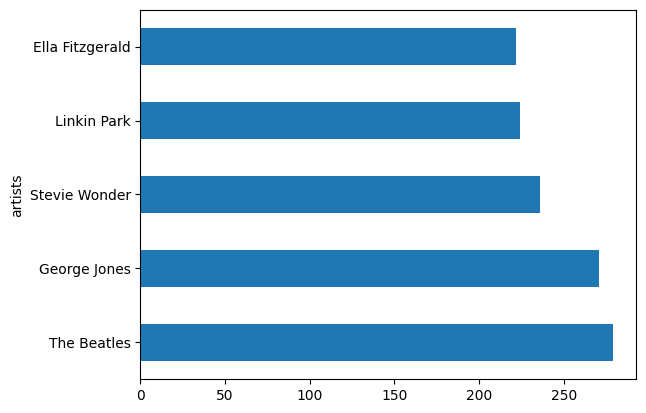

In [155]:
top_five_artists.plot.barh()
plt.show()

Top 5 Loudest Tracks

In [156]:
top_five_loudest_tracks = df[["loudness","track_name"]].sort_values(by="loudness",ascending=False)[:5]

In [157]:
top_five_loudest_tracks

,loudness,track_name
17574,4.532,Fate Dance
59225,3.156,Islamic Capitalism
38840,2.574,Time Bomb
59337,1.864,A Better World Is Possible
37738,1.821,TIPO HARIEL - SEI QUE E RARIDADE -


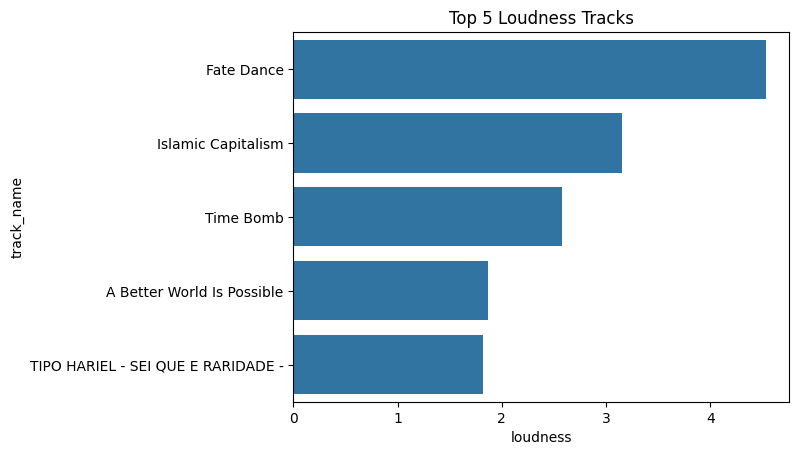

In [158]:
plt.Figure(figsize=(12,7))
sns.barplot(x="loudness",y="track_name",data = top_five_loudest_tracks)
plt.title("Top 5 Loudness Tracks")
plt.show()

Artist With The Most Danceability Song 

In [159]:
Top_Five_Artists_Danceable_Songs = df[["danceability","track_name","artists"]].sort_values(by="danceability",ascending=False)[:5]

In [160]:
Top_Five_Artists_Danceable_Songs

,danceability,track_name,artists
111635,0.985,Sol Clap,Quantic
66576,0.984,Medicaid Baby,That Girl Lay Lay
24916,0.983,Inspiration,Delano Smith
73374,0.982,Daily Routines,Oliver Schories
13353,0.981,Bitches,dj funk


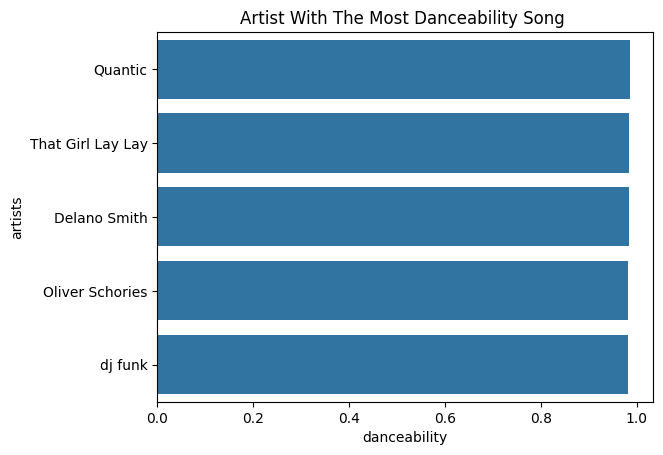

In [161]:
plt.Figure(figsize=(12,7))
sns.barplot(x="danceability",y="artists",data=Top_Five_Artists_Danceable_Songs)
plt.title("Artist With The Most Danceability Song ")
plt.show()

Top 10 Instrumentalness Tracks

In [162]:
df.info()

<class 'pandas.DataFrame'>
Index: 113999 entries, 0 to 113999
Data columns (total 22 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0.1      113999 non-null  int64  
 1   Unnamed: 0        113999 non-null  int64  
 2   track_id          113999 non-null  str    
 3   artists           113999 non-null  str    
 4   album_name        113999 non-null  str    
 5   track_name        113999 non-null  str    
 6   popularity        113999 non-null  int64  
 7   duration_ms       113999 non-null  int64  
 8   explicit          113999 non-null  bool   
 9   danceability      113999 non-null  float64
 10  energy            113999 non-null  float64
 11  key               113999 non-null  int64  
 12  loudness          113999 non-null  float64
 13  mode              113999 non-null  int64  
 14  speechiness       113999 non-null  float64
 15  acousticness      113999 non-null  float64
 16  instrumentalness  113999 non-null  f

In [163]:
top_ten_instrumental_tracks = df[["instrumentalness","track_name","artists"]].sort_values(by="instrumentalness",ascending=False)[:10]

In [164]:
top_ten_instrumental_tracks

,instrumentalness,track_name,artists
101050,1.0,Brown Sleep Noise,Sleep Miracle
101575,1.0,Large Industrial Air Conditioner,Sleep Baby Sleep;Baby Sleep Through the Night;...
101919,1.0,Hair Dryer,Baby Sweet Dream
101725,1.0,Air Conditioner Sound,White Noise for Babies
101735,1.0,Brown Noise 148 LPF,Granular
101723,1.0,Fan Whir,White Noise for Babies;Natural White Noise for...
113688,1.0,Ruido Rosa Puro - Una Hora Versión,El Ruido Blanco
101585,1.0,Brown Noise For Sleep 5,Granular
101566,1.0,Fan Whir,Soothing White Noise for Relaxation;Sleepiciou...
101892,1.0,Pink Noise For Sleep 8,Granular


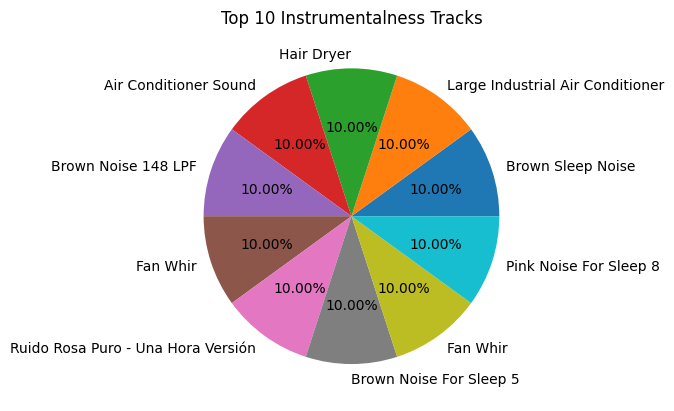

In [165]:
plt.Figure(figsize=(12,7))
plt.pie(x="instrumentalness",data=top_ten_instrumental_tracks,autopct="%1.2f%%",labels=top_ten_instrumental_tracks.track_name)
plt.title("Top 10 Instrumentalness Tracks")
plt.show()

In [166]:
df.info()

<class 'pandas.DataFrame'>
Index: 113999 entries, 0 to 113999
Data columns (total 22 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0.1      113999 non-null  int64  
 1   Unnamed: 0        113999 non-null  int64  
 2   track_id          113999 non-null  str    
 3   artists           113999 non-null  str    
 4   album_name        113999 non-null  str    
 5   track_name        113999 non-null  str    
 6   popularity        113999 non-null  int64  
 7   duration_ms       113999 non-null  int64  
 8   explicit          113999 non-null  bool   
 9   danceability      113999 non-null  float64
 10  energy            113999 non-null  float64
 11  key               113999 non-null  int64  
 12  loudness          113999 non-null  float64
 13  mode              113999 non-null  int64  
 14  speechiness       113999 non-null  float64
 15  acousticness      113999 non-null  float64
 16  instrumentalness  113999 non-null  f

Top 10 Popularity Tracks

In [167]:
top_ten_Popularity_tracks = df[["popularity","track_name","artists"]].sort_values(by="popularity",ascending=False)[:10]

In [168]:
top_ten_Popularity_tracks 

,popularity,track_name,artists
20001,100,Unholy (feat. Kim Petras),Sam Smith;Kim Petras
81051,100,Unholy (feat. Kim Petras),Sam Smith;Kim Petras
51664,99,"Quevedo: Bzrp Music Sessions, Vol. 52",Bizarrap;Quevedo
88410,98,La Bachata,Manuel Turizo
30003,98,I'm Good (Blue),David Guetta;Bebe Rexha
68303,98,La Bachata,Manuel Turizo
89411,98,La Bachata,Manuel Turizo
81210,98,I'm Good (Blue),David Guetta;Bebe Rexha
67356,98,La Bachata,Manuel Turizo
20008,98,I'm Good (Blue),David Guetta;Bebe Rexha


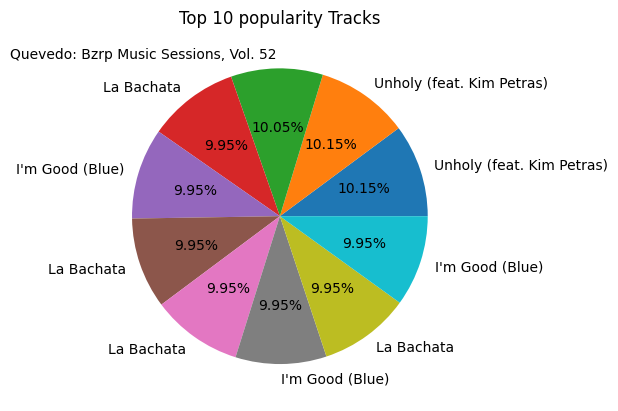

In [169]:
plt.Figure(figsize=(12,7))
plt.pie(x="popularity",data=top_ten_Popularity_tracks,autopct="%1.2f%%",labels=top_ten_Popularity_tracks.track_name)
plt.title("Top 10 popularity Tracks")
plt.show()

Top 5 acousticness Tracks

In [170]:
Top_Five_acousticness_tracks = df[["acousticness","track_name","artists"]].sort_values(by="acousticness",ascending=False)[:5]

In [171]:
Top_Five_acousticness_tracks


,acousticness,track_name,artists
16725,0.996,"Piano Sonata No.14 in C Minor, K. 457: 2c. Ada...",Wolfgang Amadeus Mozart;Claire-Marie Le Guay
16776,0.996,12 Variations on ‘Je suis Lindor’ from ‘Le Bar...,Wolfgang Amadeus Mozart;Danielle Laval
79227,0.996,Summer Light,Aaren Hughes
101794,0.996,Soft Baby Lullabies,Baby Sleep Music;Baby Lullaby;Monarch Baby Lul...
39208,0.996,"Kinderszenen, Op. 15: 7. Träumerei",Robert Schumann;Daniel Barenboim


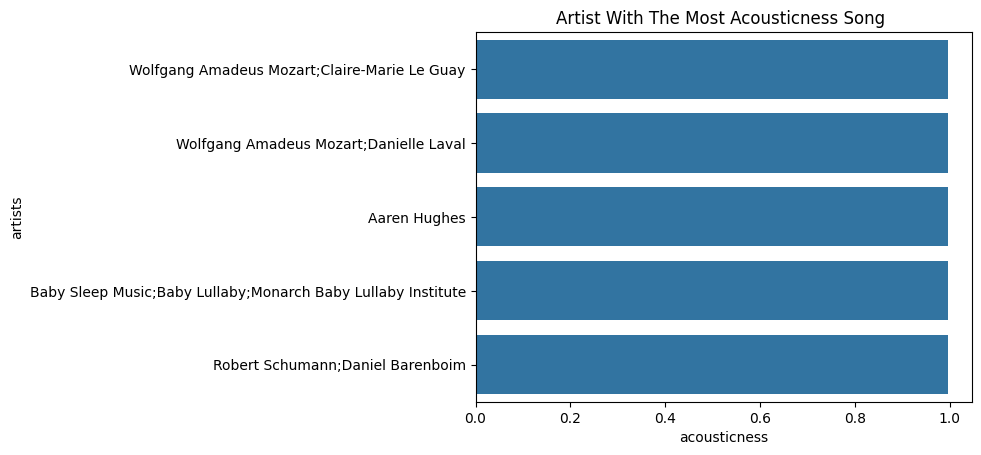

In [172]:
plt.Figure(figsize=(12,7))
sns.barplot(x="acousticness",y="artists",data=Top_Five_acousticness_tracks)
plt.title("Artist With The Most Acousticness Song ")
plt.show()

In [173]:
df.info()

<class 'pandas.DataFrame'>
Index: 113999 entries, 0 to 113999
Data columns (total 22 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0.1      113999 non-null  int64  
 1   Unnamed: 0        113999 non-null  int64  
 2   track_id          113999 non-null  str    
 3   artists           113999 non-null  str    
 4   album_name        113999 non-null  str    
 5   track_name        113999 non-null  str    
 6   popularity        113999 non-null  int64  
 7   duration_ms       113999 non-null  int64  
 8   explicit          113999 non-null  bool   
 9   danceability      113999 non-null  float64
 10  energy            113999 non-null  float64
 11  key               113999 non-null  int64  
 12  loudness          113999 non-null  float64
 13  mode              113999 non-null  int64  
 14  speechiness       113999 non-null  float64
 15  acousticness      113999 non-null  float64
 16  instrumentalness  113999 non-null  f

Top 10 energy Tracks

In [174]:
Top_Ten_energy_tracks = df[["energy","track_name","artists"]].sort_values(by="energy",ascending=False)[:10]

In [175]:
Top_Ten_energy_tracks

,energy,track_name,artists
58391,1.0,Impulso Biomecanico,Amduscia
101991,1.0,Zen Rain,Rain Sounds
101964,1.0,Rain Sound: Outdoors,Rain Sounds XLE Library
46578,1.0,Bass Be Louder - Edit,Scott Brown
101719,1.0,Heavy Rain on a Metal Rooftop,Sound Ideas
101895,1.0,Meeresrauschen ohne Musik,Meeresrauschen
101929,1.0,Rain and Thunder,Thunder Storm
101924,1.0,Clear Rain,Rain for Sleep
22947,1.0,Do Lacre ao Lucro,Surra
101946,1.0,A Big Old Downpour,White Noise Research


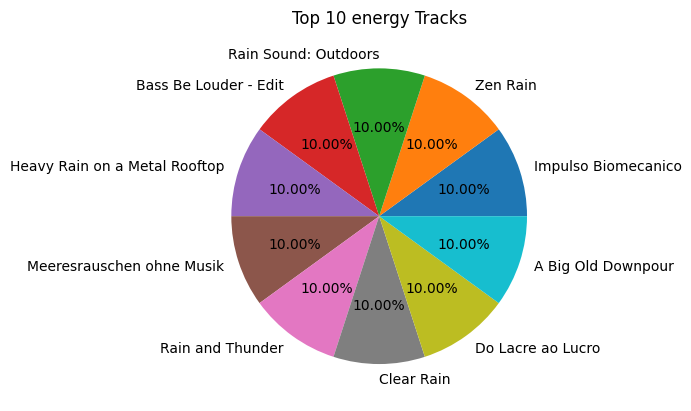

In [176]:
plt.Figure(figsize=(12,7))
plt.pie(x="energy",data=Top_Ten_energy_tracks,autopct="%1.2f%%",labels=Top_Ten_energy_tracks.track_name)
plt.title("Top 10 energy Tracks")
plt.show()

In [177]:
# ───  FEATURE ENGINEERING ───────────────────────────────────────────────────

# Encode 'explicit' (bool → int)
df['explicit'] = df['explicit'].astype(int)

# Duration: convert ms to minutes
df['duration_min'] = df['duration_ms'] / 60000

# Audio features to use as predictors
AUDIO_FEATURES = [
    'danceability', 'energy', 'key', 'loudness', 'mode',
    'speechiness', 'acousticness', 'instrumentalness',
    'liveness', 'valence', 'tempo', 'time_signature',
    'explicit', 'duration_min'
]

print('Features selected:', AUDIO_FEATURES)

Features selected: ['danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'explicit', 'duration_min']


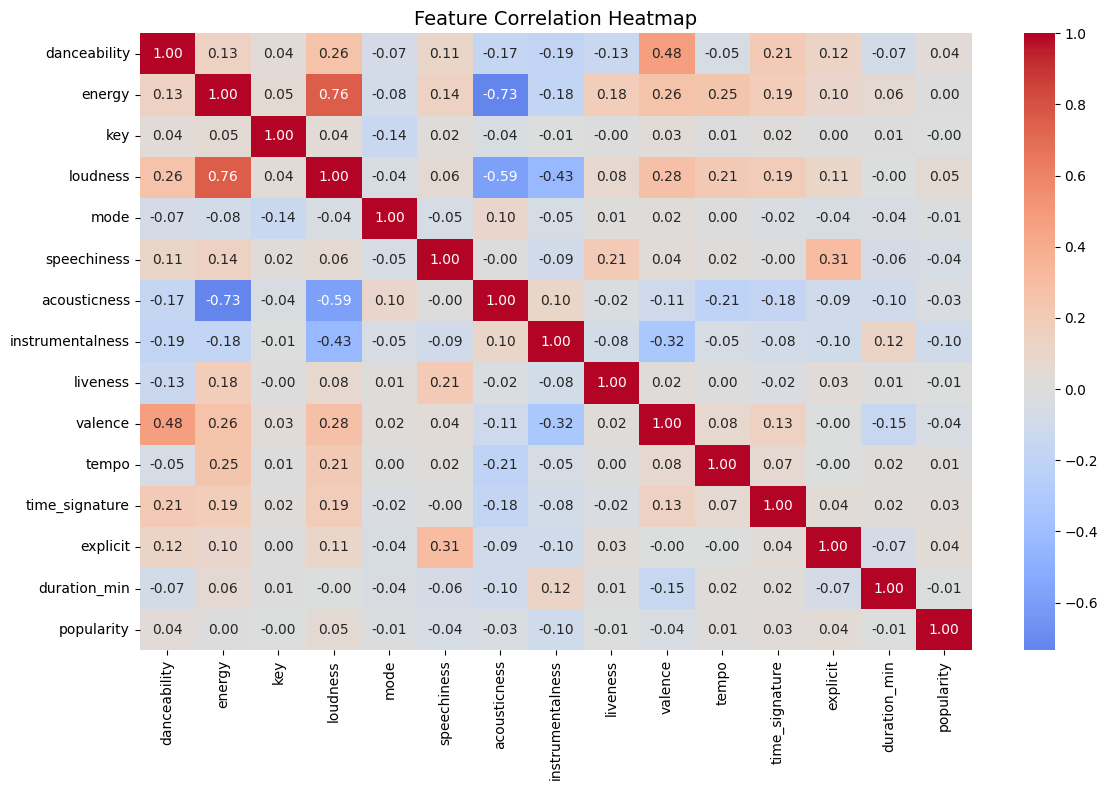


Correlation with Popularity:
loudness            0.050420
explicit            0.044078
danceability        0.035444
time_signature      0.031076
tempo               0.013212
energy              0.001053
key                -0.003847
liveness           -0.005397
duration_min       -0.007129
mode               -0.013948
acousticness       -0.025458
valence            -0.040522
speechiness        -0.044930
instrumentalness   -0.095147
Name: popularity, dtype: float64


In [178]:
# ───  EDA: FEATURE CORRELATION ──────────────────────────────────────────────
plt.figure(figsize=(12, 8))
corr_matrix = df[AUDIO_FEATURES + ['popularity']].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

# Top correlated features with popularity
print('\nCorrelation with Popularity:')
print(corr_matrix['popularity'].sort_values(ascending=False)[1:])

---
## 🎯 Task 1: REGRESSION — Predict Popularity Score

In [179]:
# ───  REGRESSION SETUP ──────────────────────────────────────────────────────
X_reg = df[AUDIO_FEATURES]
y_reg = df['popularity']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# Scale features
scaler_r = StandardScaler()
X_train_r_sc = scaler_r.fit_transform(X_train_r)
X_test_r_sc  = scaler_r.transform(X_test_r)

print(f'Train: {X_train_r.shape}, Test: {X_test_r.shape}')

Train: (91199, 14), Test: (22800, 14)


In [180]:
# ───  LINEAR REGRESSION (Baseline) ─────────────────────────────────────────
lr = LinearRegression()
lr.fit(X_train_r_sc, y_train_r)
y_pred_lr = lr.predict(X_test_r_sc)

print('=== Linear Regression ===')
print(f'MAE  : {mean_absolute_error(y_test_r, y_pred_lr):.2f}')
print(f'RMSE : {np.sqrt(mean_squared_error(y_test_r, y_pred_lr)):.2f}')
print(f'R²   : {r2_score(y_test_r, y_pred_lr):.4f}')

=== Linear Regression ===
MAE  : 18.41
RMSE : 22.03
R²   : 0.0213


In [181]:
# ───  RANDOM FOREST REGRESSOR ───────────────────────────────────────────────
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_reg.fit(X_train_r, y_train_r)   # RF doesn't need scaling
y_pred_rf_r = rf_reg.predict(X_test_r)

print('=== Random Forest Regressor ===')
print(f'MAE  : {mean_absolute_error(y_test_r, y_pred_rf_r):.2f}')
print(f'RMSE : {np.sqrt(mean_squared_error(y_test_r, y_pred_rf_r)):.2f}')
print(f'R²   : {r2_score(y_test_r, y_pred_rf_r):.4f}')

=== Random Forest Regressor ===
MAE  : 10.54
RMSE : 14.88
R²   : 0.5536


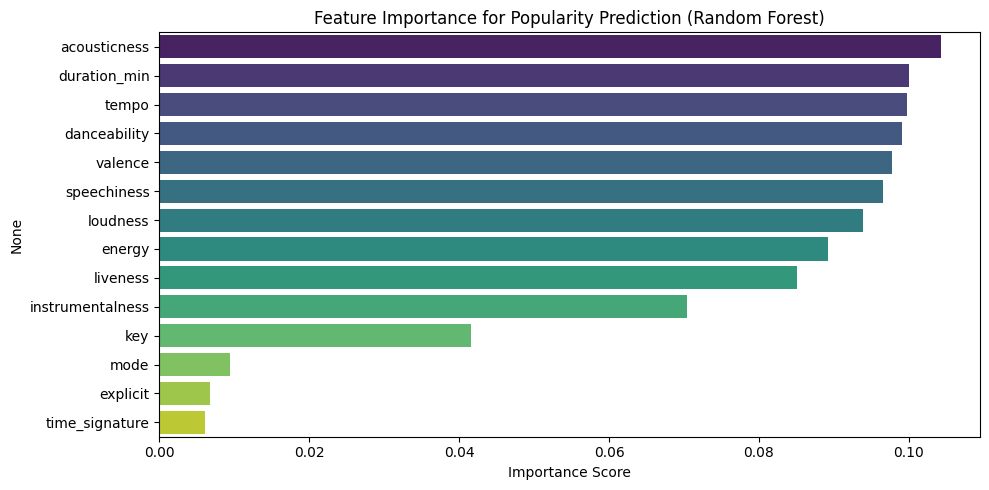

In [182]:
# ───  FEATURE IMPORTANCE (Regression) ──────────────────────────────────────
importances_r = pd.Series(rf_reg.feature_importances_, index=AUDIO_FEATURES).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=importances_r.values, y=importances_r.index, palette='viridis')
plt.title('Feature Importance for Popularity Prediction (Random Forest)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

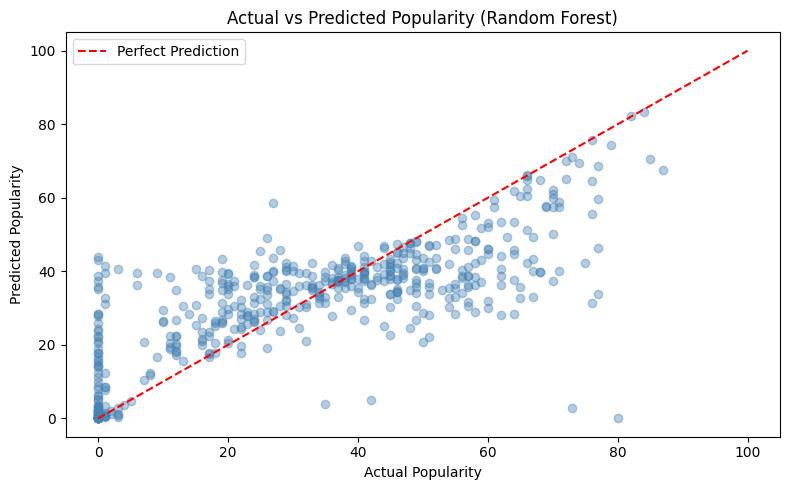

In [183]:
# ───  ACTUAL vs PREDICTED PLOT ─────────────────────────────────────────────
plt.figure(figsize=(8, 5))
plt.scatter(y_test_r[:500], y_pred_rf_r[:500], alpha=0.4, color='steelblue')
plt.plot([0, 100], [0, 100], 'r--', label='Perfect Prediction')
plt.xlabel('Actual Popularity')
plt.ylabel('Predicted Popularity')
plt.title('Actual vs Predicted Popularity (Random Forest)')
plt.legend()
plt.tight_layout()
plt.show()

---
## 🎯 Task 2: CLASSIFICATION — Predict Track Genre

In [184]:
# ───  CLASSIFICATION SETUP ────────────────────────────────────────────────
# Use top 10 genres for faster training (remove this filter for full 114 genres)
top_genres = df['track_genre'].value_counts().head(10).index
df_cls = df[df['track_genre'].isin(top_genres)].copy()

le = LabelEncoder()
df_cls['genre_encoded'] = le.fit_transform(df_cls['track_genre'])

X_cls = df_cls[AUDIO_FEATURES]
y_cls = df_cls['genre_encoded']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)

print(f'Genres: {list(le.classes_)}')
print(f'Train: {X_train_c.shape}, Test: {X_test_c.shape}')

Genres: ['acoustic', 'afrobeat', 'alt-rock', 'alternative', 'ambient', 'anime', 'black-metal', 'bluegrass', 'blues', 'brazil']
Train: (8000, 14), Test: (2000, 14)


In [185]:
# ───  DECISION TREE (Baseline Classifier) ─────────────────────────────────
dt = DecisionTreeClassifier(max_depth=10, random_state=42)
dt.fit(X_train_c, y_train_c)
y_pred_dt = dt.predict(X_test_c)

print('=== Decision Tree Classifier ===')
print(f'Accuracy: {accuracy_score(y_test_c, y_pred_dt):.4f}')

=== Decision Tree Classifier ===
Accuracy: 0.4700


In [186]:
# ───  RANDOM FOREST CLASSIFIER ────────────────────────────────────────────
rf_cls = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_cls.fit(X_train_c, y_train_c)
y_pred_rf_c = rf_cls.predict(X_test_c)

print('=== Random Forest Classifier ===')
print(f'Accuracy: {accuracy_score(y_test_c, y_pred_rf_c):.4f}')
print()
print(classification_report(y_test_c, y_pred_rf_c, target_names=le.classes_))

=== Random Forest Classifier ===
Accuracy: 0.5585

              precision    recall  f1-score   support

    acoustic       0.53      0.55      0.54       200
    afrobeat       0.54      0.69      0.60       200
    alt-rock       0.18      0.20      0.19       200
 alternative       0.31      0.25      0.28       200
     ambient       0.78      0.85      0.81       200
       anime       0.65      0.56      0.60       200
 black-metal       0.87      0.91      0.89       200
   bluegrass       0.65      0.68      0.67       200
       blues       0.59      0.41      0.49       200
      brazil       0.48      0.50      0.49       200

    accuracy                           0.56      2000
   macro avg       0.56      0.56      0.55      2000
weighted avg       0.56      0.56      0.55      2000



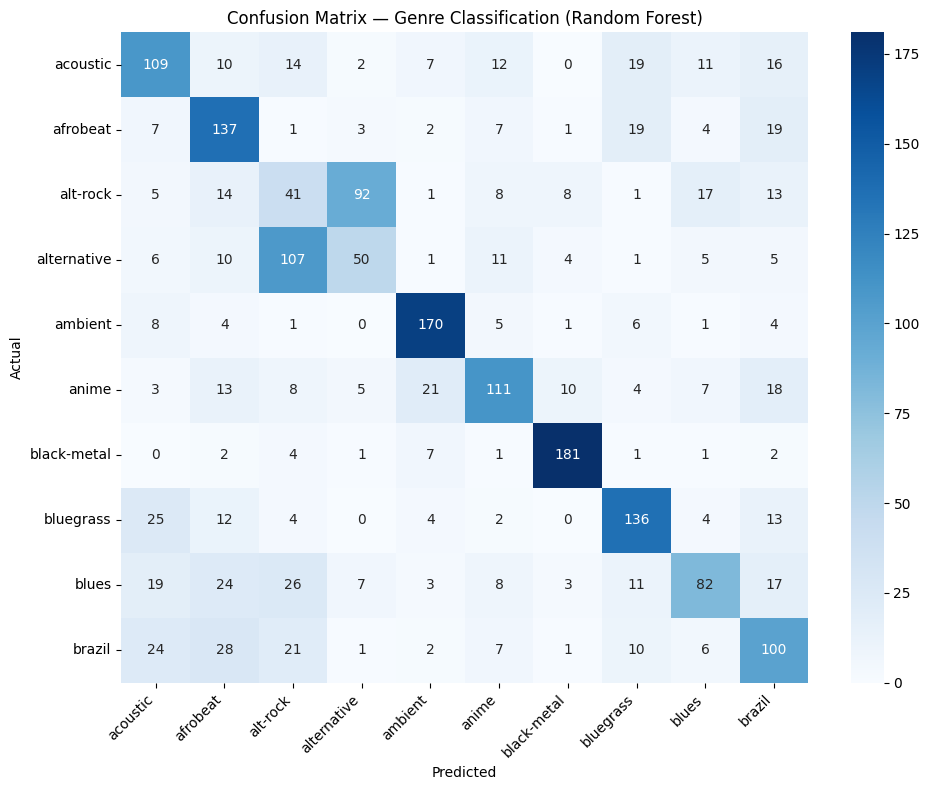

In [187]:
# ───  CONFUSION MATRIX ────────────────────────────────────────────────────
cm = confusion_matrix(y_test_c, y_pred_rf_c)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix — Genre Classification (Random Forest)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

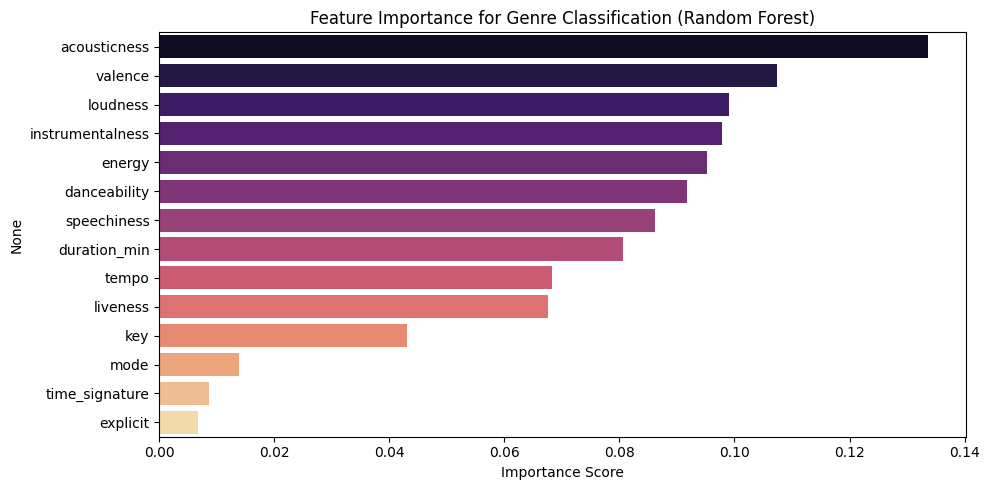

In [ ]:
# ───  FEATURE IMPORTANCE (Classification) ─────────────────────────────────
importances_c = pd.Series(rf_cls.feature_importances_, index=AUDIO_FEATURES).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=importances_c.values, y=importances_c.index, palette='magma')
plt.title('Feature Importance for Genre Classification (Random Forest)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [189]:
# ───  MODEL COMPARISON SUMMARY ────────────────────────────────────────────
print('='*55)
print('          MODEL PERFORMANCE SUMMARY')
print('='*55)
print()
print('── REGRESSION (Popularity Prediction) ─────────────────')
print(f'  Linear Regression  → R²: {r2_score(y_test_r, y_pred_lr):.4f}')
print(f'  Random Forest      → R²: {r2_score(y_test_r, y_pred_rf_r):.4f}  ✅ Best')
print()
print('── CLASSIFICATION (Genre Prediction) ──────────────────')
print(f'  Decision Tree      → Acc: {accuracy_score(y_test_c, y_pred_dt):.4f}')
print(f'  Random Forest      → Acc: {accuracy_score(y_test_c, y_pred_rf_c):.4f}  ✅ Best')
print('='*55)

          MODEL PERFORMANCE SUMMARY

── REGRESSION (Popularity Prediction) ─────────────────
  Linear Regression  → R²: 0.0213
  Random Forest      → R²: 0.5536  ✅ Best

── CLASSIFICATION (Genre Prediction) ──────────────────
  Decision Tree      → Acc: 0.4700
  Random Forest      → Acc: 0.5585  ✅ Best


In [ ]:
# ───  PREDICT ON NEW TRACK (DEMO) ─────────────────────────────────────────
# Try predicting for a custom track with given audio features
new_track = pd.DataFrame([{
    'danceability': 0.75,
    'energy': 0.82,
    'key': 5,
    'loudness': -5.2,
    'mode': 1,
    'speechiness': 0.05,
    'acousticness': 0.10,
    'instrumentalness': 0.0,
    'liveness': 0.12,
    'valence': 0.65,
    'tempo': 125.0,
    'time_signature': 4,
    'explicit': 0,
    'duration_min': 3.5
}])

pred_popularity = rf_reg.predict(new_track)[0]
pred_genre_idx  = rf_cls.predict(new_track)[0]
pred_genre      = le.inverse_transform([pred_genre_idx])[0]

print(f'🎵 Predicted Popularity Score : {pred_popularity:.1f} / 100')
print(f'🎸 Predicted Genre             : {pred_genre}')

🎵 Predicted Popularity Score : 38.7 / 100
🎸 Predicted Genre             : anime
